# Directory structure for the dataset 
``` 
data/
├── delhi_airshed_positive_64x64/      # kiln = label 1
└── delhi_airshed_negetive_64x64/      # non-kiln = label 0


In [1]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import torch
import torch.nn as nn
from torchvision.models import resnet50
import torch.optim as optim
from tqdm import tqdm


In [2]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

In [3]:
class BrickKilnMicroDataset(Dataset):
    def __init__(self, pos_dir, neg_dir, transform):
        self.samples = []
        self.transform = transform

        for f in os.listdir(pos_dir):
            if f.endswith('.png'):
                self.samples.append((os.path.join(pos_dir, f), 1))
        for f in os.listdir(neg_dir):
            if f.endswith('.png'):
                self.samples.append((os.path.join(neg_dir, f), 0))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label
    
    

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [5]:
model = resnet50(pretrained=True)
model.fc = nn.Linear(2048, 1)  
model = model.to(device)

/opt/anaconda3/envs/rishabh_sat/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/rishabh_sat/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
dataset = BrickKilnMicroDataset(
    "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/micro_patches/delhi_airshed_positive_64x64",
    "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/micro_patches/delhi_airshed_negetive_64x64",
    transform
)
loader = DataLoader(dataset, batch_size=512, shuffle=True, num_workers=8, pin_memory=True)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(50):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch} - Loss: {total_loss / len(loader)}")
torch.save(model.state_dict(), f"micro_embedding_model_{epoch}.pth")

  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:07<00:00,  1.22it/s]


Epoch 0 - Loss: 0.3275578286912706


100%|██████████| 9/9 [00:05<00:00,  1.70it/s]


Epoch 1 - Loss: 0.036795197468664914


...

Epoch 47 - Loss: 0.000752947053923789


100%|██████████| 9/9 [00:05<00:00,  1.61it/s]


Epoch 48 - Loss: 0.0006867254010608627


100%|██████████| 9/9 [00:05<00:00,  1.52it/s]


Epoch 49 - Loss: 0.007129062452198316


In [7]:

import torchvision.transforms as T

# Load pretrained ResNet-50
model = resnet50(pretrained=True)
model.fc = torch.nn.Identity()  # remove classification head
model = model.to(device).eval()

# Image transform
transform = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_embeddings(image_dir):
    features = []
    filenames = []

    image_files = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))
    ])

    for fname in tqdm(image_files, desc=f"Extracting: {os.path.basename(image_dir)}"):
        img_path = os.path.join(image_dir, fname)
        image = Image.open(img_path).convert("RGB")
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = model(image_tensor).squeeze(0).cpu()
            features.append(feat)
            filenames.append(fname)

    features = torch.stack(features)
    return features, filenames

# Paths
paths = {
    "positive": "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/micro_patches/delhi_airshed_positive_64x64",
    "negative": "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/micro_patches/delhi_airshed_negetive_64x64",
    "unlabeled": "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/brick_kiln_crops/micro_patches/lucknow_airshed_64x64_unlabeled"
}

save_root = "./embeddings_micro"

os.makedirs(save_root, exist_ok=True)

# Extract and save
for key, path in paths.items():
    feats, fnames = extract_embeddings(path)
    torch.save({
        "embeddings": feats,
        "filenames": fnames
    }, os.path.join(save_root, f"{key}_micro_embeddings.pt"))


Extracting: lucknow_airshed_64x64_unlabeled: 100%|██████████| 59800/59800 [09:24<00:00, 105.94it/s]


# start mircro label embedding uncertainity calcuation from here 


In [4]:
import torch

neg = torch.load("./embeddings_micro/negative_micro_embeddings.pt")["embeddings"]
pos = torch.load("./embeddings_micro/positive_micro_embeddings.pt")["embeddings"]
unlabeled = torch.load("./embeddings_micro/unlabeled_micro_embeddings.pt")["embeddings"]
print(type(neg), neg.shape)
print(type(pos), pos.shape)
print(type(unlabeled), unlabeled.shape)

<class 'torch.Tensor'> torch.Size([3348, 2048])
<class 'torch.Tensor'> torch.Size([773, 2048])
<class 'torch.Tensor'> torch.Size([59800, 2048])


In [6]:
# Stack labeled pool
# import torch.nn.functional as F

# labeled = torch.cat([pos, neg], dim=0)  # shape: (P+N, D)
# print("Labeled pool shape:", labeled.shape)
# labeled_norm = F.normalize(labeled, dim=1)
# unlabeled_norm = F.normalize(unlabeled, dim=1)
# print("Labeled pool normalized shape:", labeled_norm.shape)
# print("Unlabeled pool normalized shape:", unlabeled_norm.shape)

In [ ]:
import torch
import ot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance
import torch

neg = torch.load("./embeddings_micro/negative_micro_embeddings.pt")["embeddings"]
pos = torch.load("./embeddings_micro/positive_micro_embeddings.pt")["embeddings"]
unlabeled = torch.load("./embeddings_micro/unlabeled_micro_embeddings.pt")["embeddings"]
labeled_emb = torch.cat([pos, neg], dim=0)  
print("Labeled pool shape:", labeled_emb.shape)
print("Unlabeled pool shape:", unlabeled.shape)
labeled_emb = labeled_emb.to("cuda:3")
unlabeled_emb = unlabeled.to("cuda:3")


Labeled pool shape: torch.Size([4121, 2048])
Unlabeled pool shape: torch.Size([59800, 2048])


In [ ]:

# # --- Load embeddings ---
# labeled = torch.load("PATH_TO_YOUR_LABELED_MICRO_EMBEDDINGS.pt")      # dict: ['embeddings', 'filenames']
# unlabeled = torch.load("PATH_TO_YOUR_UNLABELED_MICRO_EMBEDDINGS.pt")  # dict: ['embeddings', 'filenames']

# labeled_emb = labeled['embeddings']
# unlabeled_emb = unlabeled['embeddings']
labeled_norm = torch.nn.functional.normalize(labeled_emb, dim=1)
unlabeled_norm = torch.nn.functional.normalize(unlabeled_emb, dim=1)

# --- Cosine similarity (U x L) ---
similarity = torch.matmul(unlabeled_norm, labeled_norm.T)

# Method 1: Max similarity
max_sim, _ = torch.max(similarity, dim=1)
uncertainty_max = 1 - max_sim

# Method 2: Avg top-k similarity
topk_vals, _ = torch.topk(similarity, k=5, dim=1)
avg_topk_sim = topk_vals.mean(dim=1)
uncertainty_topk = 1 - avg_topk_sim

# Method 3: Margin between top-2
top2_vals, _ = torch.topk(similarity, k=2, dim=1)
uncertainty_margin = top2_vals[:, 0] - top2_vals[:, 1]

# Method 4: Softmax entropy
probs = torch.nn.functional.softmax(similarity, dim=1)
entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)

# Method 5: GCNU
local_sim = torch.matmul(unlabeled_norm, unlabeled_norm.T)
_, top10_local = torch.topk(local_sim, k=11, dim=1)  # include self
local_density = torch.stack([
    local_sim[i, idx[1:]].mean() for i, idx in enumerate(top10_local)
])
uncertainty_gcnu = (1 - max_sim) * (1 / (local_density + 1e-6))

# Method 6: MMD (RBF kernel)
def rbf_kernel(x, y, sigma=5.0):
    dist = torch.cdist(x, y)
    return torch.exp(-dist ** 2 / (2 * sigma ** 2))

def mmd_single_patch(u, ref_bank, sigma=5.0):
    K_uu = 1
    K_rr = rbf_kernel(ref_bank, ref_bank, sigma).mean()
    K_ur = rbf_kernel(u, ref_bank, sigma).mean()
    return K_uu + K_rr - 2 * K_ur

sigma = 5.0
mmd_uncertainty = []
for i in range(unlabeled_emb.shape[0]):
    u = unlabeled_emb[i:i+1]
    score = mmd_single_patch(u, labeled_emb, sigma=sigma)
    mmd_uncertainty.append(score)
mmd_uncertainty = torch.tensor(mmd_uncertainty)

# Method 7: Wasserstein (high-dimensional, patchwise via POT)
Xs = labeled_emb.cpu().numpy()
Xt = unlabeled_emb.cpu().numpy()
a = torch.ones(Xs.shape[0]) / Xs.shape[0]
a = a.numpy()
uncertainty_wasserstein = []
for i in range(Xt.shape[0]):
    mi = ot.dist(Xt[i:i+1], Xs)
    wi = ot.emd2([1.0], a, mi)
    uncertainty_wasserstein.append(wi)
uncertainty_wasserstein = torch.tensor(uncertainty_wasserstein)

# Method 8: Wasserstein (PCA-10D aggregate)
n_components = 10
all_emb = torch.cat([labeled_emb, unlabeled_emb], dim=0).cpu().numpy()
pca = PCA(n_components=n_components, random_state=42)
pca.fit(all_emb)
Xs_proj = pca.transform(labeled_emb.cpu().numpy())
Xt_proj = pca.transform(unlabeled_emb.cpu().numpy())
uncertainty_wasserstein_pca = []
for i in range(Xt_proj.shape[0]):
    wscores = [
        wasserstein_distance([Xt_proj[i, j]], Xs_proj[:, j])
        for j in range(n_components)
    ]
    uncertainty_wasserstein_pca.append(sum(wscores) / len(wscores))
uncertainty_wasserstein_pca = torch.tensor(uncertainty_wasserstein_pca)

# --- Save all uncertainty scores ---
uncertainty_dict = {
    "filenames": unlabeled['filenames'],
    "uncertainty_max": uncertainty_max.cpu().numpy().tolist(),
    "uncertainty_topk": uncertainty_topk.cpu().numpy().tolist(),
    "uncertainty_margin": uncertainty_margin.cpu().numpy().tolist(),
    "uncertainty_entropy": entropy.cpu().numpy().tolist(),
    "uncertainty_gcnu": uncertainty_gcnu.cpu().numpy().tolist(),
    "uncertainty_mmd": mmd_uncertainty.cpu().numpy().tolist(),
    "uncertainty_wasserstein": uncertainty_wasserstein.cpu().numpy().tolist(),
    "uncertainty_wasserstein_pca": uncertainty_wasserstein_pca.cpu().numpy().tolist(),
}
torch.save(uncertainty_dict, "micro_uncertainty_scores.pt")

# --- Plot all uncertainties ---
fig, axs = plt.subplots(4, 2, figsize=(16, 16))
sns.histplot(uncertainty_max.cpu().numpy(), bins=30, ax=axs[0, 0], kde=True)
axs[0, 0].set_title("Uncertainty: 1 - max(similarity)")
sns.histplot(uncertainty_topk.cpu().numpy(), bins=30, ax=axs[0, 1], kde=True)
axs[0, 1].set_title("Uncertainty: 1 - mean(top-5 similarity)")
sns.histplot(uncertainty_margin.cpu().numpy(), bins=30, ax=axs[1, 0], kde=True)
axs[1, 0].set_title("Uncertainty: Top-1 - Top-2 margin")
sns.histplot(entropy.cpu().numpy(), bins=30, ax=axs[1, 1], kde=True)
axs[1, 1].set_title("Uncertainty: Entropy of Softmax(similarity)")
sns.histplot(uncertainty_gcnu.cpu().numpy(), bins=30, ax=axs[2, 0], kde=True)
axs[2, 0].set_title("Uncertainty: GCNU")
sns.histplot(mmd_uncertainty.cpu().numpy(), bins=30, ax=axs[2, 1], kde=True)
axs[2, 1].set_title("Uncertainty: MMD (micro)")
sns.histplot(uncertainty_wasserstein.cpu().numpy(), bins=30, ax=axs[3, 0], kde=True)
axs[3, 0].set_title("Uncertainty: Wasserstein (micro, high-D)")
sns.histplot(uncertainty_wasserstein_pca.cpu().numpy(), bins=30, ax=axs[3, 1], kde=True)
axs[3, 1].set_title("Uncertainty: Wasserstein (PCA, micro)")
plt.tight_layout()
plt.savefig("uncertainty_distributions_micro.png")
plt.show()


Labeled pool shape: torch.Size([4121, 2048])
Unlabeled pool shape: torch.Size([59800, 2048])


IndexError: too many indices for tensor of dimension 2

In [13]:
import torch
import os

neg_meta = torch.load("./embeddings_micro/negative_micro_embeddings.pt")
pos_meta = torch.load("./embeddings_micro/positive_micro_embeddings.pt")
unlabeled_meta = torch.load("./embeddings_micro/unlabeled_micro_embeddings.pt")

neg = neg_meta["embeddings"]
pos = pos_meta["embeddings"]
unlabeled = unlabeled_meta["embeddings"]

print(type(neg), neg.shape)
print(type(pos), pos.shape)
print(type(unlabeled), unlabeled.shape)

# Now process filenames safely for the uncertainty_dict
if isinstance(unlabeled_meta['filenames'], torch.Tensor):
    # If tensor of bytes (rare), decode to strings
    try:
        filenames = [bytes(f).decode("utf-8").strip() for f in unlabeled_meta['filenames']]
    except Exception:
        filenames = [str(f.item()) for f in unlabeled_meta['filenames']]
elif isinstance(unlabeled_meta['filenames'], list):
    filenames = unlabeled_meta['filenames']
else:
    filenames = list(unlabeled_meta['filenames'])

# When saving uncertainty_dict, make sure all uncertainty vectors have the same length as filenames

uncertainty_dict = {
    "filenames": filenames,
    "uncertainty_max": uncertainty_max.cpu().numpy().tolist(),
    "uncertainty_topk": uncertainty_topk.cpu().numpy().tolist(),
    "uncertainty_margin": uncertainty_margin.cpu().numpy().tolist(),
    "uncertainty_entropy": entropy.cpu().numpy().tolist(),
    "uncertainty_gcnu": uncertainty_gcnu.cpu().numpy().tolist(),
    "uncertainty_mmd": mmd_uncertainty.cpu().numpy().tolist(),
    "uncertainty_wasserstein": uncertainty_wasserstein.cpu().numpy().tolist(),
    "uncertainty_wasserstein_pca": uncertainty_wasserstein_pca.cpu().numpy().tolist(),
}

torch.save(uncertainty_dict, "micro_uncertainty_scores.pt")


<class 'torch.Tensor'> torch.Size([3348, 2048])
<class 'torch.Tensor'> torch.Size([773, 2048])
<class 'torch.Tensor'> torch.Size([59800, 2048])


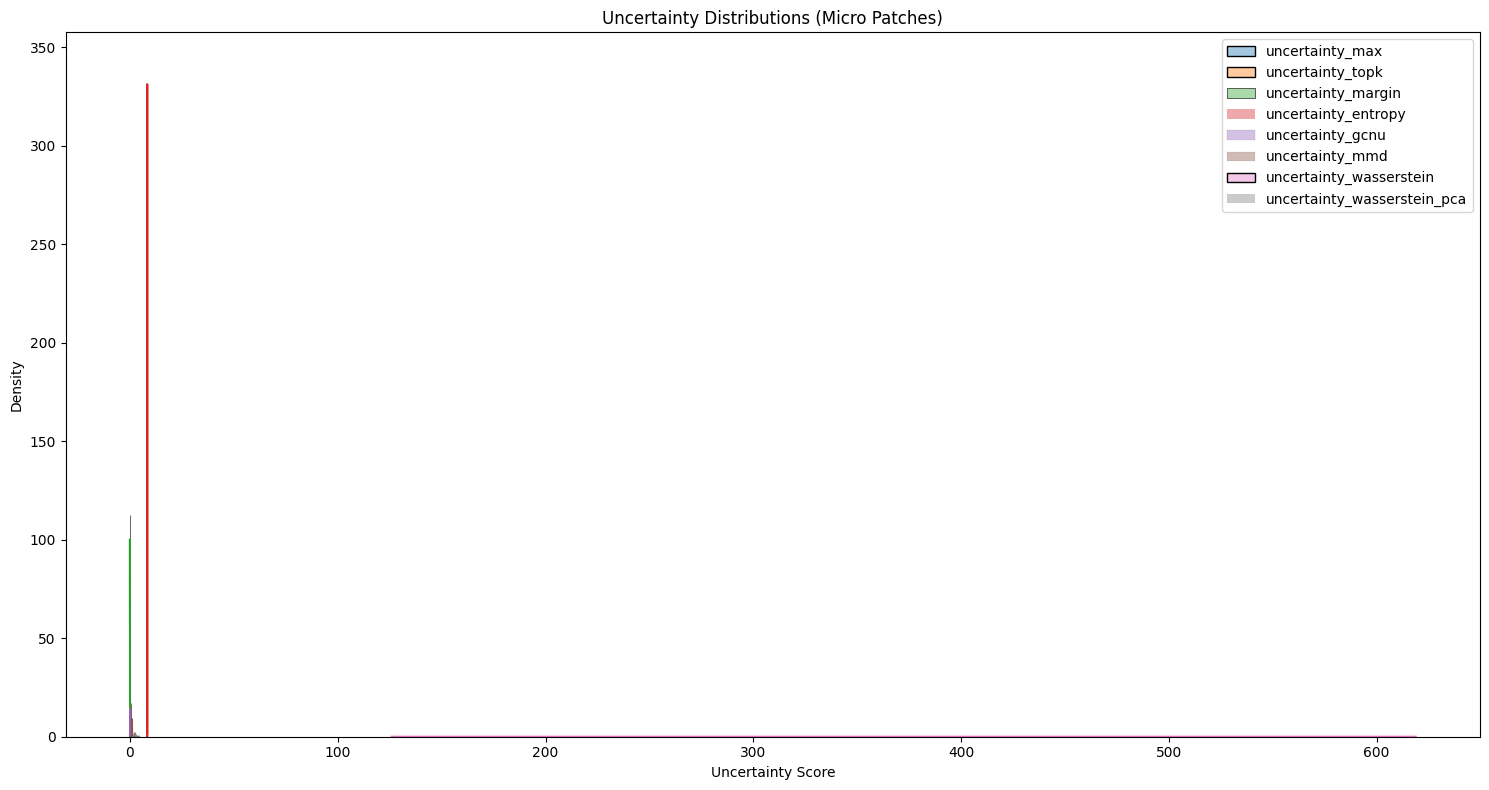

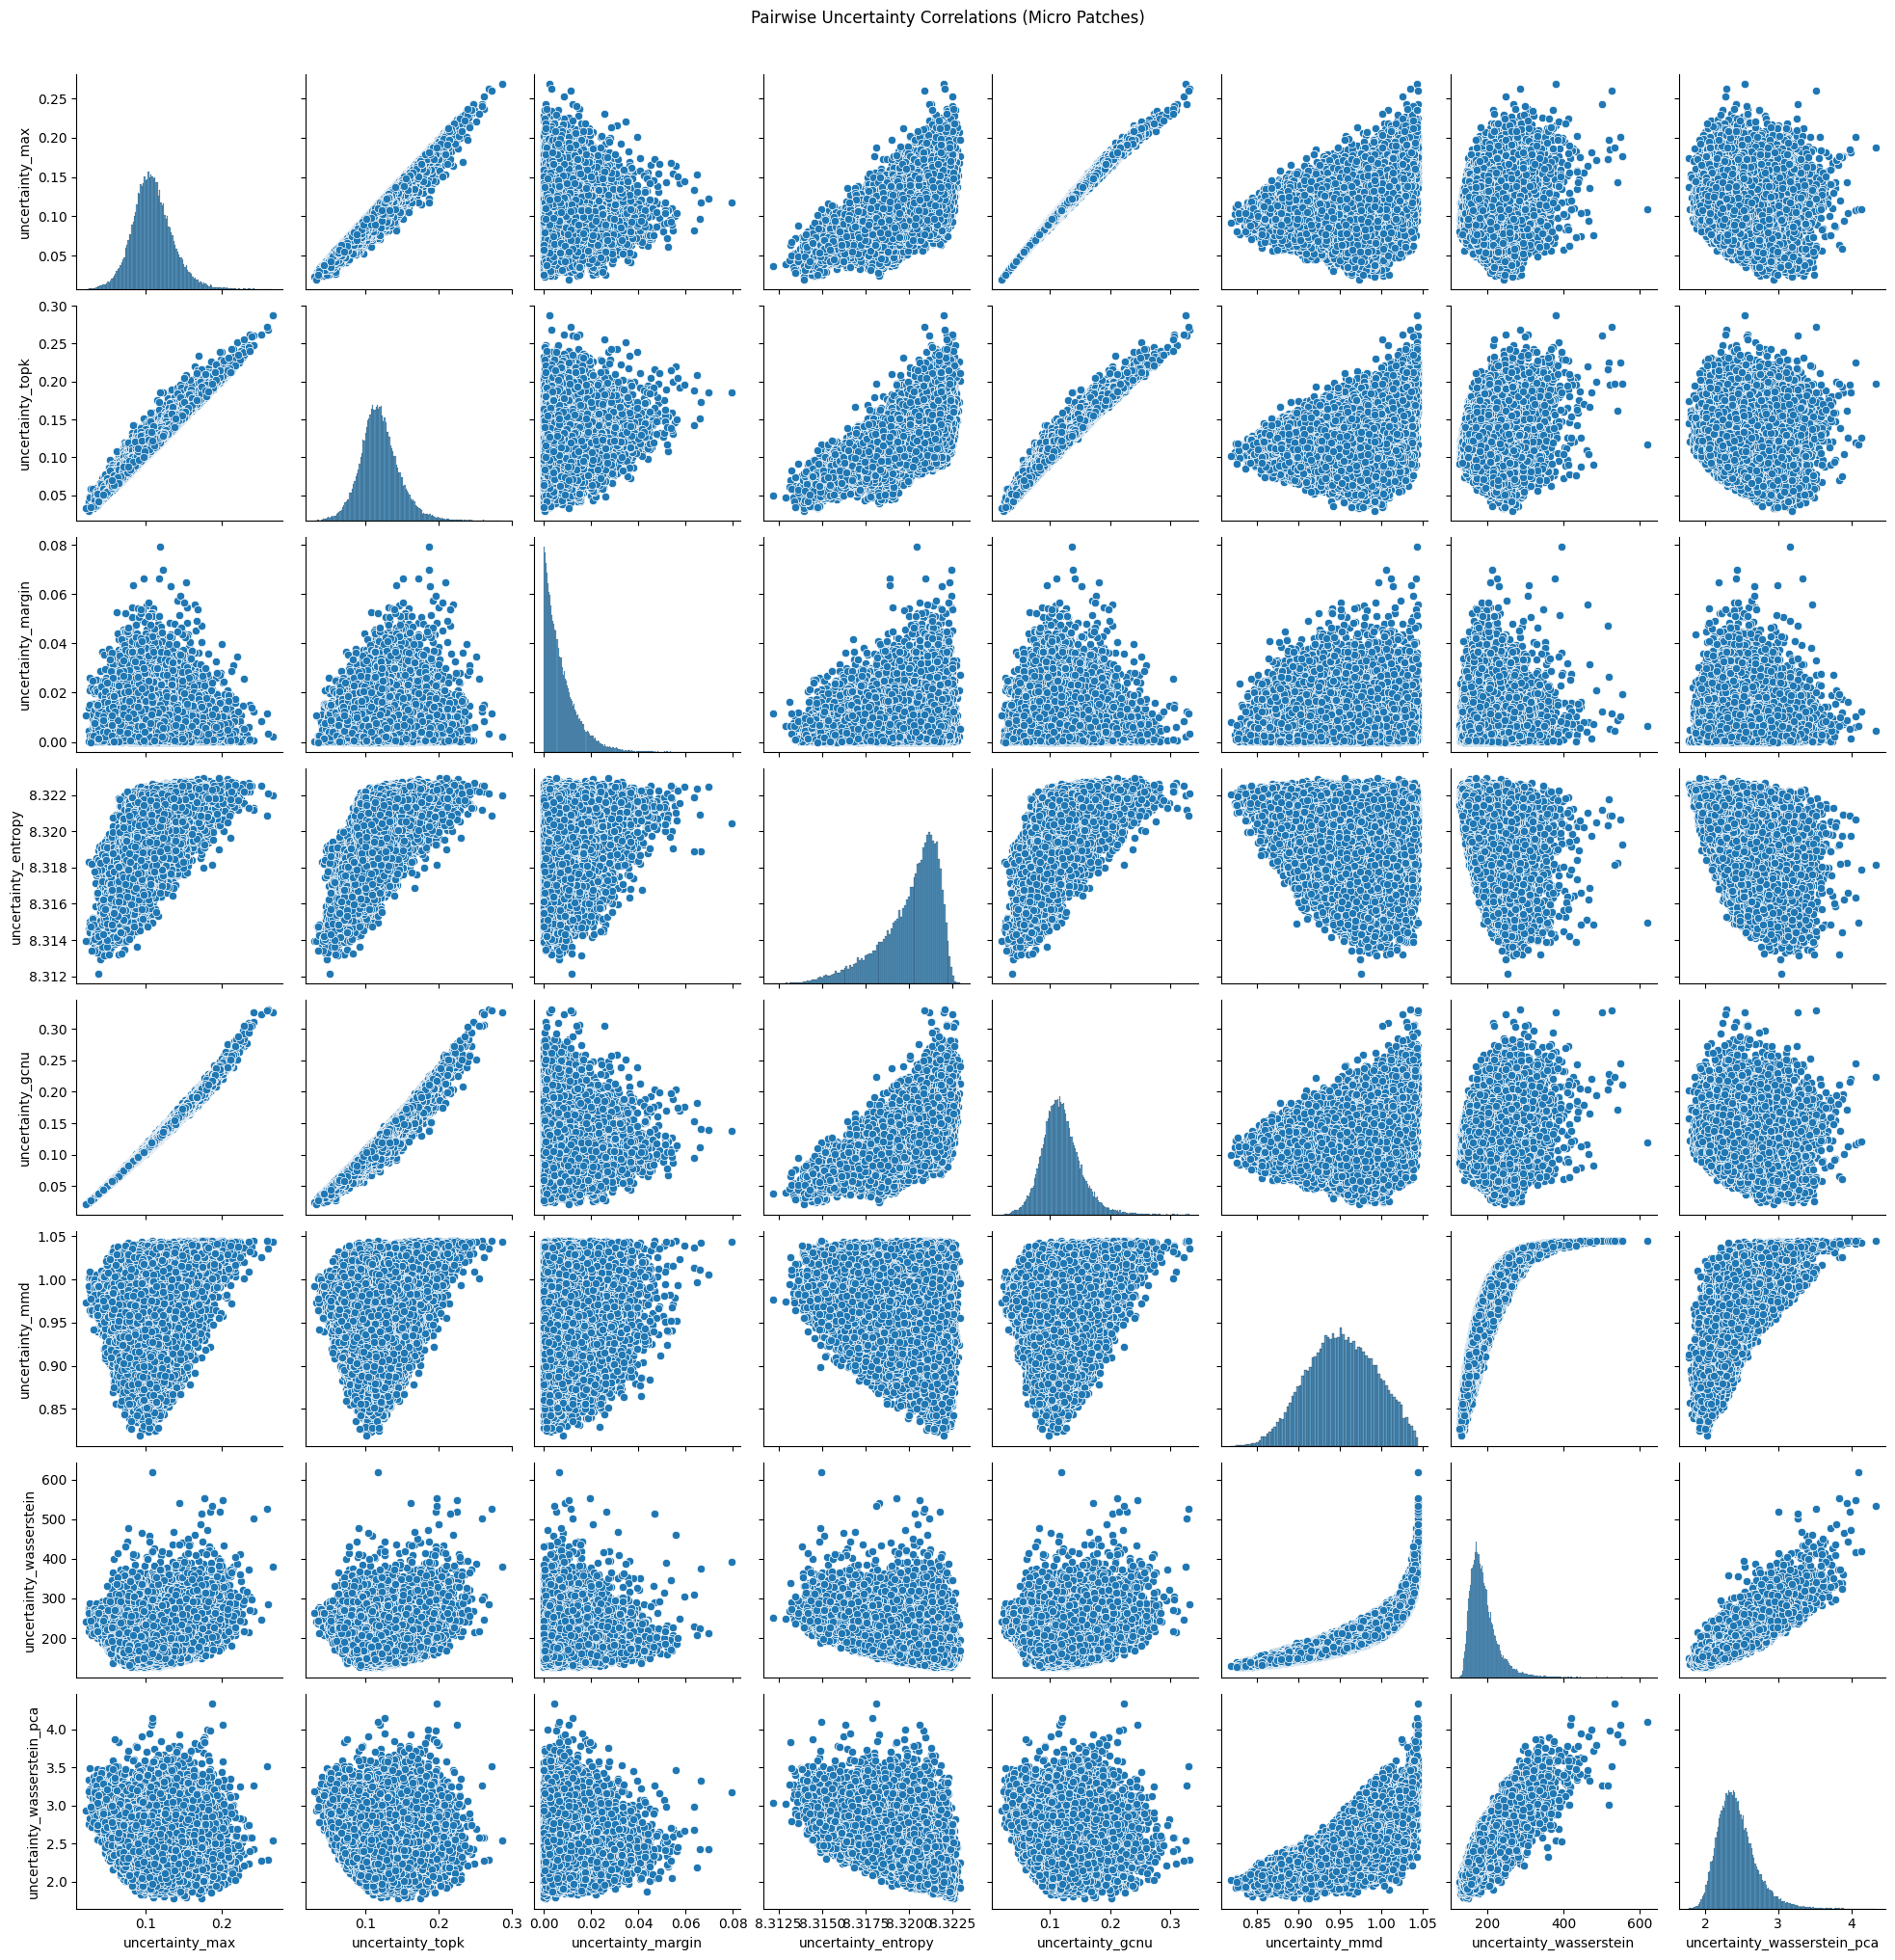

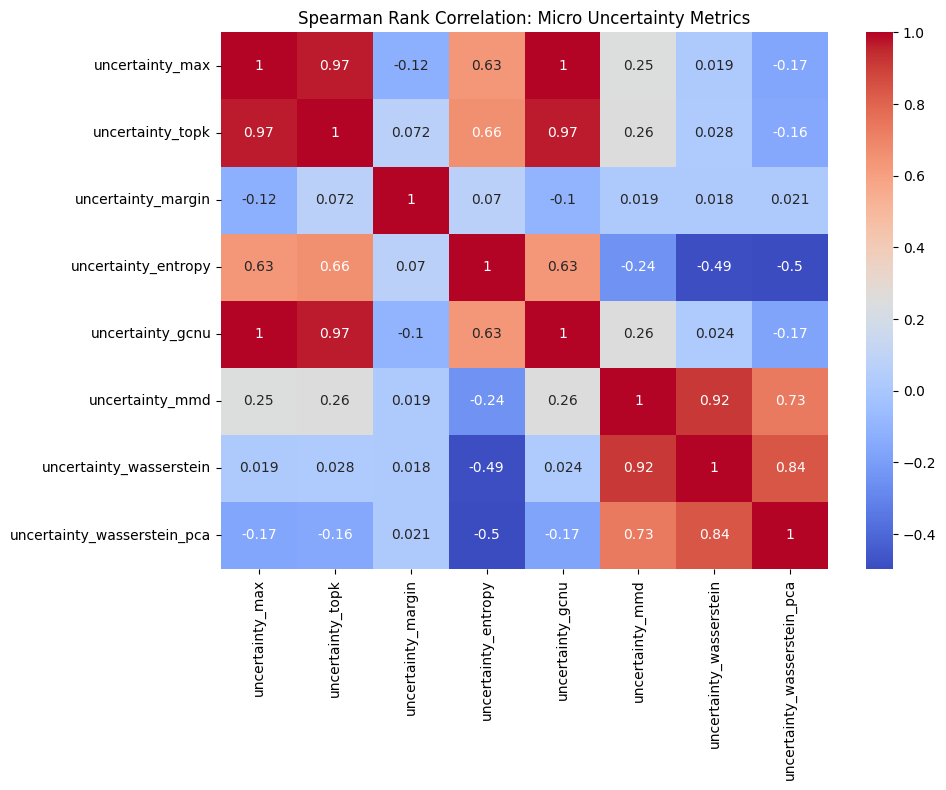

In [14]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load uncertainty metrics ---
uncertainty_dict = torch.load("micro_uncertainty_scores.pt")
df = pd.DataFrame(uncertainty_dict)

# --- Histogram overlay for comparison ---
plt.figure(figsize=(15, 8))
for col in [
    "uncertainty_max",
    "uncertainty_topk",
    "uncertainty_margin",
    "uncertainty_entropy",
    "uncertainty_gcnu",
    "uncertainty_mmd",
    "uncertainty_wasserstein",
    "uncertainty_wasserstein_pca"
]:
    sns.histplot(df[col], bins=50, stat="density", kde=True, label=col, alpha=0.4)
plt.xlabel("Uncertainty Score")
plt.ylabel("Density")
plt.legend()
plt.title("Uncertainty Distributions (Micro Patches)")
plt.tight_layout()
plt.show()

# --- Pairwise scatterplots ---
sns.pairplot(df[[
    "uncertainty_max",
    "uncertainty_topk",
    "uncertainty_margin",
    "uncertainty_entropy",
    "uncertainty_gcnu",
    "uncertainty_mmd",
    "uncertainty_wasserstein",
    "uncertainty_wasserstein_pca"
]])
plt.suptitle("Pairwise Uncertainty Correlations (Micro Patches)", y=1.02)
plt.show()

# --- Spearman correlation heatmap ---
corrs = df[[
    "uncertainty_max",
    "uncertainty_topk",
    "uncertainty_margin",
    "uncertainty_entropy",
    "uncertainty_gcnu",
    "uncertainty_mmd",
    "uncertainty_wasserstein",
    "uncertainty_wasserstein_pca"
]].corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corrs, annot=True, cmap="coolwarm")
plt.title("Spearman Rank Correlation: Micro Uncertainty Metrics")
plt.tight_layout()
plt.show()


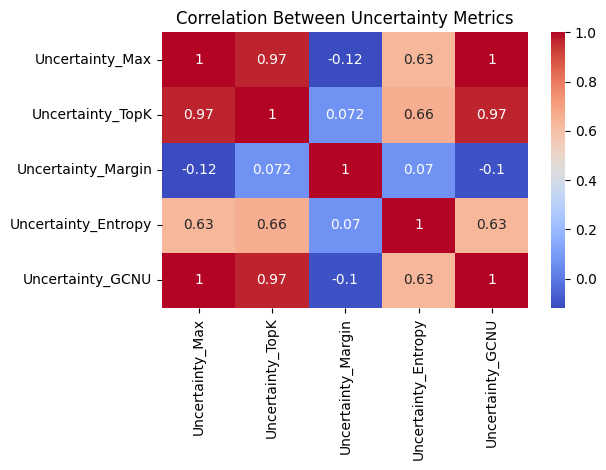

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Uncertainty_Max": uncertainty_max.cpu().numpy(),
    "Uncertainty_TopK": uncertainty_topk.cpu().numpy(),
    "Uncertainty_Margin": uncertainty_margin.cpu().numpy(),
    "Uncertainty_Entropy": entropy.cpu().numpy(),
    "Uncertainty_GCNU": uncertainty_gcnu.cpu().numpy()
}

df = pd.DataFrame(data)
corr = df.corr(method="spearman")  # or method="pearson"
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Uncertainty Metrics")
plt.tight_layout()
plt.savefig("uncertainty_correlation_micro.png")
plt.show()


In [48]:
from scipy.stats import kendalltau

# Example: compare top-k rankings (tau correlation)
tau1, _ = kendalltau(df["Uncertainty_Max"], df["Uncertainty_GCNU"])
print(f"Kendall Tau between Max and GCNU: {tau1:.3f}")
tau2, _ = kendalltau(df["Uncertainty_TopK"], df["Uncertainty_GCNU"])
print(f"Kendall Tau between TopK and GCNU: {tau2:.3f}")
tau3, _ = kendalltau(df["Uncertainty_Margin"], df["Uncertainty_GCNU"])
print(f"Kendall Tau between Margin and GCNU: {tau3:.3f}")
tau4, _ = kendalltau(df["Uncertainty_Entropy"], df["Uncertainty_GCNU"])
print(f"Kendall Tau between Entropy and GCNU: {tau4:.3f}")  



Kendall Tau between Max and GCNU: 0.962
Kendall Tau between TopK and GCNU: 0.856
Kendall Tau between Margin and GCNU: -0.070
Kendall Tau between Entropy and GCNU: 0.453


In [ ]:
k = 50
top_max = set(df.sort_values("Uncertainty_Max", ascending=False).index[:k])
top_gcnu = set(df.sort_values("Uncertainty_GCNU", ascending=False).index[:k])
overlap1 = len(top_max & top_gcnu) / k
print(f"Top-{k} overlap between Max and GCNU: {overlap1:.2%}")
top_max = set(df.sort_values("Uncertainty_Max", ascending=False).index[:k])
top_gcnu = set(df.sort_values("Uncertainty_GCNU", ascending=False).index[:k])
overlap2 = len(top_max & top_gcnu) / k
print(f"Top-{k} overlap between Max and GCNU: {overlap2:.2%}")
top_margin = set(df.sort_values("Uncertainty_Margin", ascending=False).index[:k])
overlap3 = len(top_max & top_margin) / k
print(f"Top-{k} overlap between Max and Margin: {overlap3:.2%}")
top_entropy = set(df.sort_values("Uncertainty_Entropy", ascending=False).index[:k])
overlap4 = len(top_max & top_entropy) / k
print(f"Top-{k} overlap between Max and Entropy: {overlap4:.2%}")



Top-50 overlap between Max and GCNU: 86.00%
Top-50 overlap between Max and GCNU: 86.00%
Top-50 overlap between Max and Margin: 0.00%
Top-50 overlap between Max and Entropy: 4.00%


In [58]:
import torch

# Load filenames from saved embedding metadata
unlabeled_meta = torch.load("./embeddings_micro/unlabeled_micro_embeddings.pt")  # contains ['filenames']
filenames = unlabeled_meta["filenames"]  # list of filenames

# Ensure GCNU scores are on CPU and converted to float
uncertainty_dict = {
    fn: float(score) for fn, score in zip(filenames, uncertainty_gcnu.cpu())
}
print(f"Uncertainty scores for {len(uncertainty_dict)} files.")
print("Example scores:", list(uncertainty_dict.items())[:5])  # print first 5 for verification
# Save as a dictionary mapping filenames → GCNU score
torch.save(uncertainty_dict, "./embeddings_micro/micro_level_uncertainty_scores.pt")



Uncertainty scores for 59800 files.
Example scores: [('8980130_3077352_x0_y0_crop37700.png', 0.1711616814136505), ('8980130_3077352_x0_y128_crop37720.png', 0.08783859759569168), ('8980130_3077352_x0_y192_crop37730.png', 0.12108451873064041), ('8980130_3077352_x0_y256_crop37740.png', 0.09995158761739731), ('8980130_3077352_x0_y320_crop37750.png', 0.09913379698991776)]


In [56]:
#check if the  .pt and key
# Load the saved uncertainty scores
uncertainty_scores = torch.load("./embeddings_micro/micro_level_uncertainty_scores.pt")
# Ensure it's a dictionary
if isinstance(uncertainty_scores, dict):
    print("Uncertainty scores loaded successfully.")
else:
    print("Error: Loaded uncertainty scores are not a dictionary.") 
# Check if the keys are filenames
if all(isinstance(k, str) for k in uncertainty_scores.keys()):
    print("All keys are filenames.")
else:
    print("Error: Not all keys are filenames.")
    print("Invalid keys found:")
    for k in uncertainty_scores.keys():
        if not isinstance(k, str):
            print(f" - {k} (type: {type(k)})")

Uncertainty scores loaded successfully.
All keys are filenames.
